<a href="https://colab.research.google.com/github/isabelamoreiramendes29/CursoIA/blob/main/BasicoPython%26Bibliotecas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Espaço para seus insights (escreva aqui)

- **Insight 1 (padrão):As variáveis de vibração (vibration_x, vibration_y e vibration_z) apresentaram distribuição relativamente concentrada, enquanto algumas variáveis derivadas de wavelets exibiram maior dispersão. Além disso, observou-se correlação entre certas características de vibração e a necessidade de manutenção (maintenance_required).

- **Insight 2 (qualidade de dados):Após a análise inicial, não foram identificados valores ausentes ou registros duplicados relevantes. Os dados apresentaram consistência nos tipos das variáveis e não houve necessidade de correções estruturais significativas.

- **Insight 3 (hipótese/modelo futuro):As variáveis relacionadas à vibração, temperatura e características wavelet parecem possuir potencial preditivo para identificar falhas futuras. Como próximo passo, recomenda-se a construção de modelos de classificação, como Regressão Logística, Random Forest ou XGBoost, para prever a variável maintenance_required.  

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
#importar as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [18]:
#Leitura dataset
data = pd.read_csv('/content/drive/MyDrive/CursoIA/Aula2/petrochemical_maintenance.csv')
#LEndo as 5 primeiras linhas do dataset
data.tail()

,timestamp,equipment_id,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
4995,2025-08-12 23:52:51.509191,EQ-008,0.057703,0.028558,-0.052663,71.014561,9.747689,3019.143215,4.213003,0.329242,0.703803,-0.911752,-0.108123,-0.736190,no_fault,0
4996,2025-08-12 23:53:01.509191,EQ-005,-0.007101,-0.004121,-0.001137,70.794923,9.809861,2994.999239,5.965899,-1.373011,-1.879467,0.821554,-0.785426,1.776213,no_fault,0
4997,2025-08-12 23:53:11.509191,EQ-005,0.021151,0.005132,-0.014084,68.012785,9.173987,3030.227146,4.609235,-1.388544,-1.162725,-0.426449,-0.949630,1.363981,no_fault,0
4998,2025-08-12 23:53:21.509191,EQ-006,-0.021202,0.003962,0.016104,76.460142,10.265523,3028.423818,5.370740,-0.130070,0.425693,-0.401792,0.925138,0.547995,no_fault,0
4999,2025-08-12 23:53:31.509191,EQ-003,0.194027,0.108393,0.172600,80.483804,16.527375,2823.620810,6.521823,0.367599,-0.646518,-0.483573,-0.626398,0.792143,bearing_fault,1


In [19]:
data['fault_type'].value_counts()

,count
fault_type,
no_fault,3021
bearing_fault,755
rotor_imbalance,733
misalignment,491


In [20]:
data['equipment_id'].value_counts()

,count
equipment_id,
EQ-007,539
EQ-002,535
EQ-003,528
EQ-009,507
EQ-010,507
EQ-008,502
EQ-006,484
EQ-001,473
EQ-004,463


In [22]:
#Boas praticas de eda
df = data.copy()


**Agora, sempre que for rodar algo do dataset use o 'df'**

In [23]:
df.describe()

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,maintenance_required
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.062282,0.062142,0.061776,76.001068,11.950740,2920.493629,5.417371,-0.017568,-0.005989,-0.010578,0.021800,0.000263,0.395800
std,0.087444,0.086996,0.086654,9.396747,2.799776,120.699363,0.773510,0.995384,1.006752,1.003449,1.014089,1.005985,0.489071
min,-0.074409,-0.079232,-0.074427,53.406406,6.752987,2522.785379,3.345714,-3.841926,-3.708700,-3.468916,-3.421746,-3.403457,0.000000
25%,-0.004813,-0.003731,-0.004573,68.869254,9.782357,2834.785840,4.863258,-0.685239,-0.680994,-0.692082,-0.669576,-0.673880,0.000000
50%,0.018631,0.018196,0.019047,74.060406,10.891146,2958.352272,5.315433,-0.005531,-0.019370,-0.016875,0.023731,-0.023749,0.000000
75%,0.132800,0.130318,0.132723,82.822620,14.257743,3010.739975,5.896007,0.652951,0.679174,0.657735,0.713676,0.675060,1.000000
max,0.373233,0.365274,0.363575,110.790521,20.748306,3161.131235,8.366381,3.313657,3.394122,3.475239,3.623171,3.461276,1.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             5000 non-null   object 
 1   equipment_id          5000 non-null   object 
 2   vibration_x           5000 non-null   float64
 3   vibration_y           5000 non-null   float64
 4   vibration_z           5000 non-null   float64
 5   temperature_c         5000 non-null   float64
 6   current_a             5000 non-null   float64
 7   rpm                   5000 non-null   float64
 8   pressure_bar          5000 non-null   float64
 9   wavelet_feature_1     5000 non-null   float64
 10  wavelet_feature_2     5000 non-null   float64
 11  wavelet_feature_3     5000 non-null   float64
 12  wavelet_feature_4     5000 non-null   float64
 13  wavelet_feature_5     5000 non-null   float64
 14  fault_type            5000 non-null   object 
 15  maintenance_required 

In [26]:
print(df.isnull().sum())

timestamp               0
equipment_id            0
vibration_x             0
vibration_y             0
vibration_z             0
temperature_c           0
current_a               0
rpm                     0
pressure_bar            0
wavelet_feature_1       0
wavelet_feature_2       0
wavelet_feature_3       0
wavelet_feature_4       0
wavelet_feature_5       0
fault_type              0
maintenance_required    0
dtype: int64


In [29]:
df = df.dropna()

array([[<Axes: title={'center': 'vibration_x'}>,
        <Axes: title={'center': 'vibration_y'}>,
        <Axes: title={'center': 'vibration_z'}>,
        <Axes: title={'center': 'temperature_c'}>],
       [<Axes: title={'center': 'current_a'}>,
        <Axes: title={'center': 'rpm'}>,
        <Axes: title={'center': 'pressure_bar'}>,
        <Axes: title={'center': 'wavelet_feature_1'}>],
       [<Axes: title={'center': 'wavelet_feature_2'}>,
        <Axes: title={'center': 'wavelet_feature_3'}>,
        <Axes: title={'center': 'wavelet_feature_4'}>,
        <Axes: title={'center': 'wavelet_feature_5'}>],
       [<Axes: title={'center': 'maintenance_required'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

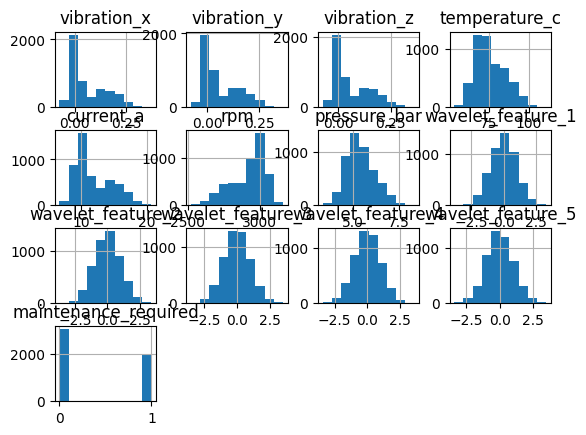

In [33]:
df.hist()

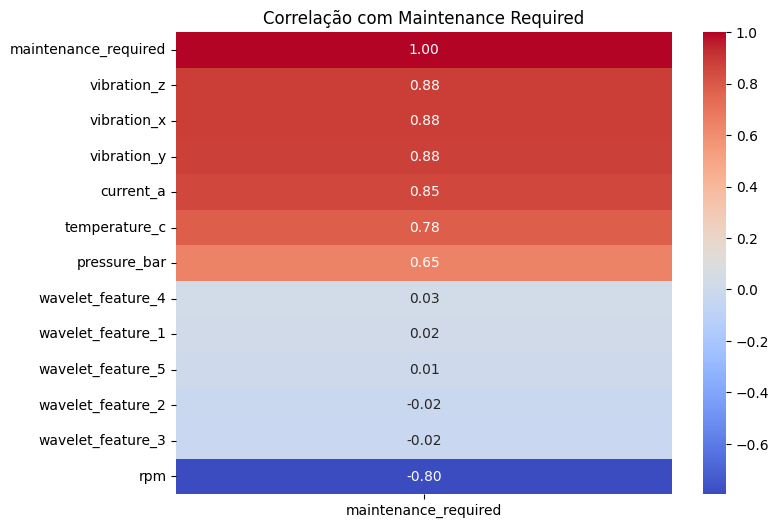

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)[['maintenance_required']].sort_values(
    by='maintenance_required',
    ascending=False
)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação com Maintenance Required')
plt.show()

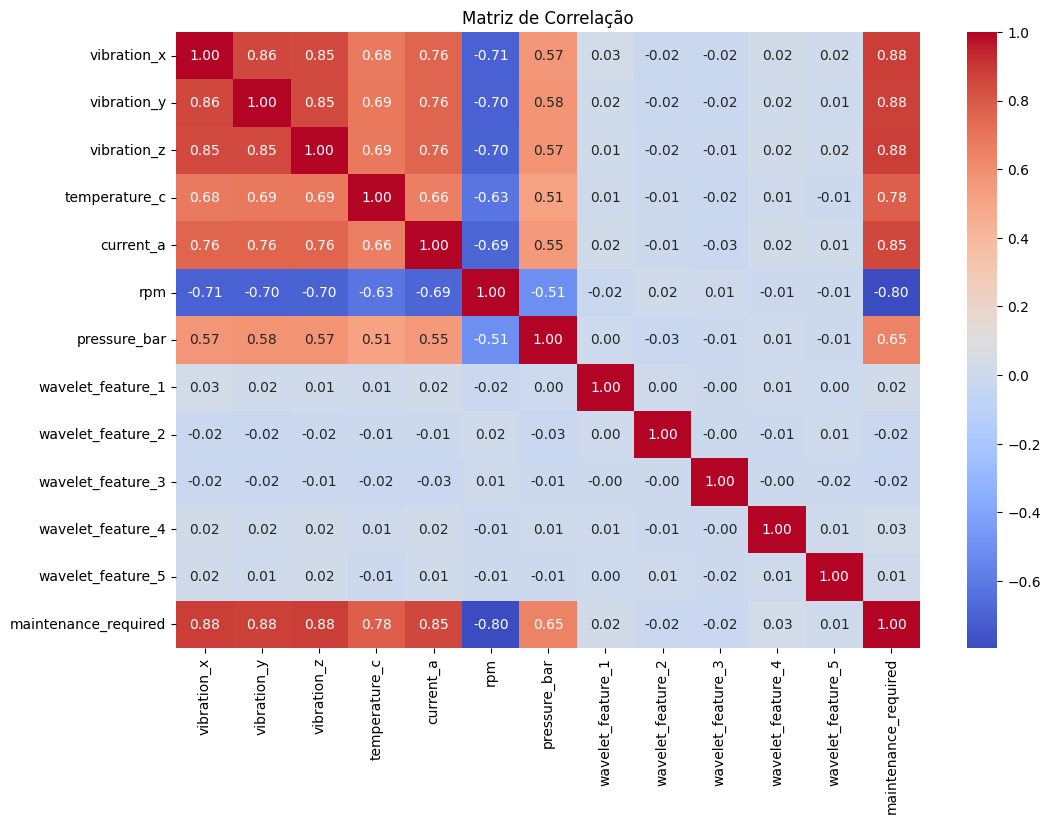

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

In [44]:
estatisticas = df.describe()
print(estatisticas)

       vibration_x  vibration_y  vibration_z  temperature_c    current_a  \
count  5000.000000  5000.000000  5000.000000    5000.000000  5000.000000   
mean      0.062282     0.062142     0.061776      76.001068    11.950740   
std       0.087444     0.086996     0.086654       9.396747     2.799776   
min      -0.074409    -0.079232    -0.074427      53.406406     6.752987   
25%      -0.004813    -0.003731    -0.004573      68.869254     9.782357   
50%       0.018631     0.018196     0.019047      74.060406    10.891146   
75%       0.132800     0.130318     0.132723      82.822620    14.257743   
max       0.373233     0.365274     0.363575     110.790521    20.748306   

               rpm  pressure_bar  wavelet_feature_1  wavelet_feature_2  \
count  5000.000000   5000.000000        5000.000000        5000.000000   
mean   2920.493629      5.417371          -0.017568          -0.005989   
std     120.699363      0.773510           0.995384           1.006752   
min    2522.785379 